In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score 
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
pd.set_option('display.max_columns', None)

In [2]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.4600,95.42882,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,1012.03436,3.9,4.0,0.0,1.0,0.0,0.057978,7.421590,12.229406,112.833694,137.38599,11.879999,10.7600,13.110001,14.0100,21.910000,0.275,0.318,0.195,0.026,1
1,10.4535,95.42859,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,1011.91230,3.9,4.0,0.0,1.0,0.0,0.057956,7.421590,12.229406,112.833694,137.38599,11.879999,10.7535,13.103500,14.0035,21.903500,0.275,0.318,0.195,0.026,1
2,10.4145,95.42721,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,1011.18120,3.9,4.0,0.0,1.0,0.0,0.057823,7.421590,12.229406,112.833694,137.38599,11.879999,10.7145,13.064501,13.9645,21.864500,0.275,0.318,0.195,0.026,1
3,9.2235,99.66392,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,1010.78680,2.7,3.0,0.0,0.0,0.0,0.003924,5.937272,11.885453,75.963730,125.13428,13.320000,10.4235,12.823500,13.7235,21.923500,0.273,0.324,0.201,0.020,1
4,9.2430,99.66399,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,1011.15370,2.7,3.0,0.0,0.0,0.0,0.003929,5.937272,11.885453,75.963730,125.13428,13.320000,10.4430,12.842999,13.7430,21.942999,0.273,0.324,0.201,0.020,1


### Target variable -> y is fire

In [3]:
X=training_df.drop('fire',axis=1)
y=training_df['fire']

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
X_train.to_csv("../Datasets/decistion_tree_X_train.csv", index=False)

In [27]:
X_test.to_csv("../Datasets/decistion_tree_X_test.csv", index=False)

In [28]:
X_train

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
86276,23.581500,30.182863,5.0815,20.782309,0.0,0.0,0.0,0.0,0.0,1013.1,970.46250,0.600000,0.0,0.0,2.0,0.129170,2.032494,10.948973,15.294704,207.407490,206.564990,29.519999,33.081500,28.081500,21.581500,18.381498,0.076,0.094,0.072,0.155
19582,16.959000,21.806984,-5.0410,11.936909,0.0,0.0,0.0,0.0,0.0,1011.3,919.23160,0.000000,0.0,0.0,0.0,0.138545,1.512834,15.328561,27.908709,260.537750,263.333440,24.119999,19.809000,25.459000,21.009000,16.809000,0.005,0.088,0.150,0.186
76324,14.174001,43.637997,1.9740,11.599044,0.0,0.0,0.0,0.0,0.0,1012.2,815.89230,0.000000,0.0,0.0,0.0,0.043197,0.912416,5.315336,13.183080,298.300660,304.992100,36.000000,18.273998,17.973999,17.973999,13.523999,0.136,0.151,0.166,0.264
87200,39.696500,27.070065,17.2465,39.359700,0.0,0.0,0.0,0.0,0.0,1002.9,1002.13367,19.800000,0.0,3.0,60.0,0.360456,5.288937,19.855560,25.969950,135.000100,136.123210,34.200000,48.746500,42.246500,39.046500,29.846500,0.018,0.125,0.034,0.081
18455,3.293500,75.322950,-0.6565,-0.988489,0.0,0.0,0.0,0.0,0.0,1022.1,885.48755,0.000000,0.0,0.0,0.0,0.014473,0.191470,14.113653,24.482647,275.855930,269.157500,45.000000,6.193500,11.593500,12.393500,14.793500,0.030,0.152,0.207,0.206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76820,15.552000,10.473747,-15.4480,6.746056,0.0,0.0,0.0,0.0,0.0,1023.3,994.37244,0.000000,0.0,0.0,0.0,0.280982,1.583402,35.647274,57.735970,33.048134,32.005356,72.000000,15.852001,17.752000,19.452000,21.802000,0.100,0.137,0.102,0.161
110268,20.286001,55.862114,11.1860,20.166687,0.0,0.0,0.0,0.0,0.0,1017.3,982.83680,0.000000,0.0,0.0,0.0,0.008225,1.050968,3.319036,6.792466,12.528798,57.994660,9.720000,22.186000,25.886002,25.786001,22.986000,0.093,0.151,0.190,0.269
103694,22.719000,36.850560,7.2190,20.714050,0.0,0.0,0.0,0.0,0.0,1013.7,1003.23060,0.000000,0.0,0.0,0.0,0.081602,1.745017,8.825508,13.551500,348.231720,343.009100,12.599999,25.619001,30.569000,29.319000,26.819000,0.129,0.147,0.150,0.172
860,10.053500,99.333230,9.9535,9.476762,0.0,0.0,0.0,0.0,3.0,1018.7,1018.20870,90.000000,100.0,0.0,0.0,0.000000,0.008230,3.976330,8.121970,84.805664,102.804260,9.000000,9.403500,14.153500,15.403500,19.503500,0.148,0.163,0.180,0.026


In [29]:
X_test

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
57526,24.078500,54.823914,14.4285,25.315160,0.0,0.0,0.0,0.0,0.0,1012.5,907.14760,0.000000,0.0,0.0,0.0,0.112685,1.354402,1.484318,1.609969,194.036270,243.435010,15.119999,25.978500,21.828500,21.578500,20.478500,0.132,0.160,0.218,0.323
32133,16.934500,48.455890,5.9845,15.446991,0.0,0.0,0.0,0.0,0.0,1014.9,1015.25867,0.900000,1.0,0.0,0.0,0.298856,0.995594,3.319036,3.545589,102.528800,113.962494,15.480000,17.684500,14.434501,22.834500,27.684500,0.190,0.014,0.003,0.091
70733,20.943499,28.005545,1.7435,18.766342,0.0,0.0,0.0,0.0,1.0,1016.5,900.42145,28.500002,0.0,0.0,95.0,0.012253,1.785594,2.305125,4.843305,38.659830,131.987140,10.080000,21.643500,24.143500,22.293499,20.143500,0.131,0.153,0.215,0.322
59482,27.838999,14.744609,-1.4110,24.194191,0.0,0.0,0.0,0.0,1.0,1015.6,846.84644,21.000000,0.0,0.0,70.0,0.641553,3.193788,16.645864,23.006226,201.571370,200.136380,57.600000,29.639000,24.239000,24.338999,21.139000,0.076,0.125,0.144,0.189
18387,27.536999,11.872372,-4.5630,26.002825,0.0,0.0,0.0,0.0,0.0,1013.1,1015.17420,18.900002,0.0,0.0,63.0,0.553462,3.243856,3.600000,4.104631,36.869990,52.124958,17.640000,31.786999,21.187000,20.437000,23.487000,0.040,0.114,0.132,0.088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91883,20.382500,36.180637,4.8825,18.655153,0.0,0.0,0.0,0.0,0.0,1010.6,891.43610,0.000000,0.0,0.0,0.0,0.018892,1.529041,3.319036,1.297998,310.601230,303.690100,6.120000,15.082500,26.132500,27.382500,26.632500,0.023,0.019,0.103,0.171
50234,34.371998,28.604473,13.5720,36.124600,0.0,0.0,0.0,0.0,0.0,1013.2,887.74260,0.000000,0.0,0.0,0.0,0.841965,3.875689,12.964998,17.227419,271.591100,280.840270,46.440000,33.072000,25.972000,20.321999,13.722000,0.134,0.180,0.253,0.336
80560,22.031500,67.043400,15.6315,23.357990,0.0,0.0,0.0,0.0,0.0,1012.6,969.76575,0.600000,0.0,1.0,0.0,0.006319,0.873084,4.024922,3.096837,10.304792,35.537766,6.840000,25.431500,32.281500,29.681500,25.981499,0.074,0.118,0.075,0.155
75854,18.895000,12.850369,-10.3050,15.776978,0.0,0.0,0.0,0.0,0.0,1017.7,969.01733,0.900000,1.0,0.0,0.0,0.427531,1.904168,5.771239,7.289444,273.576260,290.224950,20.880001,20.995000,11.795000,12.495001,15.145000,0.065,0.189,0.107,0.281


In [6]:
dt_model = DecisionTreeClassifier()


In [7]:
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')

print("Decision Tree Cross-Validation Scores: ", dt_cv_scores)
print("Decision Tree Mean Accuracy: ", np.mean(dt_cv_scores))


Decision Tree Cross-Validation Scores:  [0.7815518  0.78274708 0.7845031  0.79010042 0.79119794]
Decision Tree Mean Accuracy:  0.7860200674773657


In [8]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [9]:
# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)


In [10]:
# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.9989
Testing Accuracy: 0.8006


We can see that the model is clearly overfitting

Setting up a controlled tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [12]:
# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)


In [13]:
# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.7999
Testing Accuracy: 0.7594



Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.83      0.65      0.73     11258
           1       0.72      0.87      0.78     11522

    accuracy                           0.76     22780
   macro avg       0.77      0.76      0.76     22780
weighted avg       0.77      0.76      0.76     22780


Confusion Matrix on Test Set:
[[7328 3930]
 [1551 9971]]


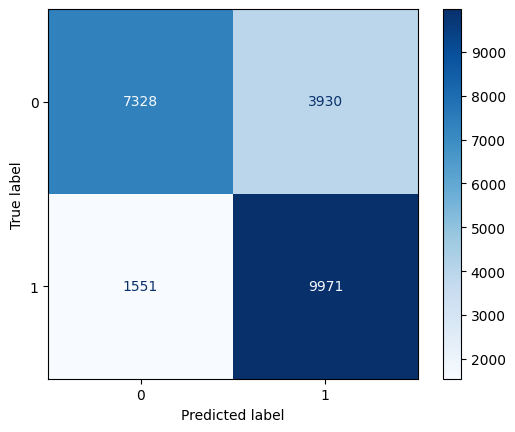

In [14]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix on Test Set:")
print(conf_matrix)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=dt_model.classes_)
disp.plot(cmap='Blues')


AUC Score: 0.8231


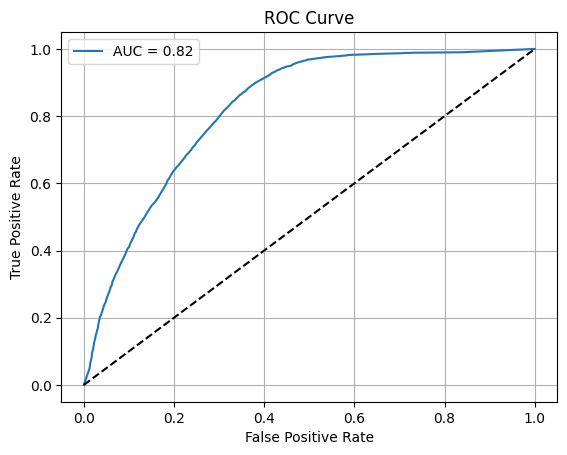

In [15]:
y_probs = dt_model.predict_proba(X_test)[:, 1]  # Get probability estimates for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()
